Target mapping: {'Q1': np.int64(0), 'Q2': np.int64(1), 'Q3': np.int64(2), 'Q4': np.int64(3)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy (XGBoost + GNB proba): 0.5650883582894914

Classification Report:
               precision    recall  f1-score   support

          Q1       0.73      0.65      0.69      2263
          Q2       0.46      0.46      0.46      1909
          Q3       0.45      0.48      0.46      1722
          Q4       0.61      0.67      0.64      1519

    accuracy                           0.57      7413
   macro avg       0.56      0.56      0.56      7413
weighted avg       0.57      0.57      0.57      7413



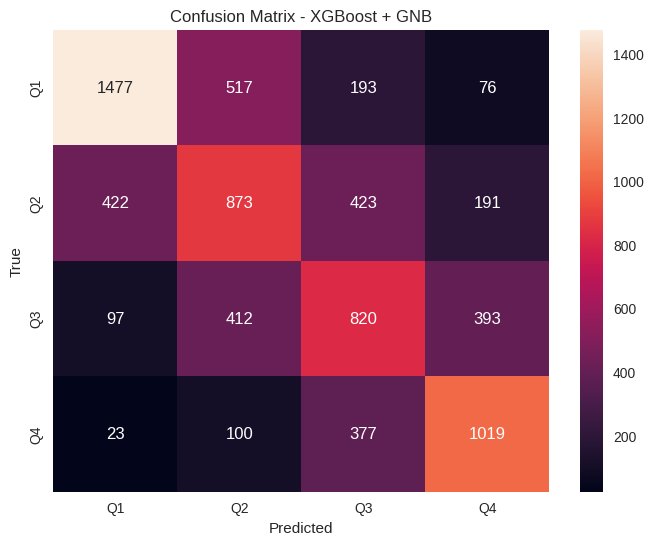

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

CV Accuracy (10-fold): 0.5681 (+/- 0.0081)


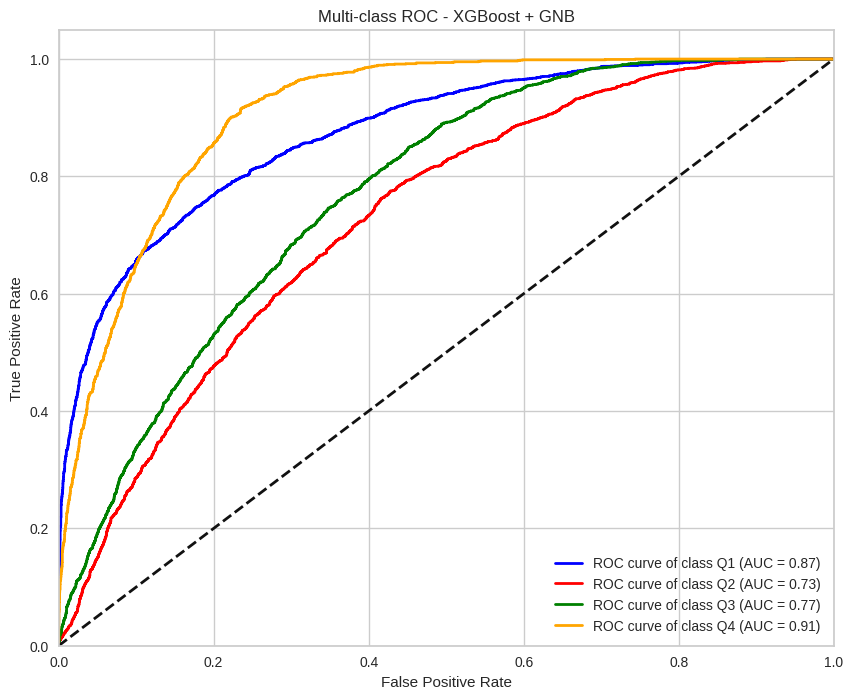

In [1]:
# ========================
# 1. Instalasi dan Impor
# ========================
!pip install xgboost yellowbrick -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from yellowbrick.classifier import roc_auc

# ========================
# 2. Baca Data (perhatikan koma desimal)
# ========================
dt = pd.read_csv('28.csv', decimal=',')   # mengubah "62,937" → 62.937

# Drop baris dengan missing (Publisher)
dt.dropna(inplace=True)

# ========================
# 3. Encode Target (SJR Best Quartile)
# ========================
le = LabelEncoder()
dt['SJR Best Quartile_enc'] = le.fit_transform(dt['SJR Best Quartile'])
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Target mapping:", target_mapping)

# ========================
# 4. Fitur dan Target
# ========================
feature_cols = ['H index', 'Total Docs. (2020)', 'Total Docs. (3years)',
                'Total Refs.', 'Total Cites (3years)',
                'Citable Docs. (3years)', 'Cites / Doc. (2years)',
                'Ref. / Doc.']
X = dt[feature_cols].values
y = dt['SJR Best Quartile_enc'].values

# ========================
# 5. Split Data (stratified)
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=10
)

# Standarisasi (opsional, tapi baik untuk GaussianNB dan stabilisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================
# 6. Gaussian Naive Bayes sebagai "base estimator"
#    - Dapatkan probabilitas kelas untuk setiap sampel
# ========================
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
proba_train = gnb.predict_proba(X_train_scaled)   # shape (n_train, n_classes)
proba_test = gnb.predict_proba(X_test_scaled)

# ========================
# 7. Gabungkan fitur asli dengan probabilitas GNB
# ========================
X_train_aug = np.hstack([X_train_scaled, proba_train])
X_test_aug = np.hstack([X_test_scaled, proba_test])

# ========================
# 8. Latih XGBoost pada fitur yang diperkaya
# ========================
xgb = XGBClassifier(n_estimators=500, random_state=0,
                    use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_aug, y_train)

# ========================
# 9. Evaluasi pada Test Set
# ========================
y_pred = xgb.predict(X_test_aug)

print("Accuracy (XGBoost + GNB proba):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred,
                                                          target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost + GNB')
plt.show()

# ========================
# 10. Cross-Validation dengan pipeline yang menyertakan GNB + XGBoost
#     (untuk menghindari kebocoran data, kita buat custom transformer)
# ========================
from sklearn.base import BaseEstimator, TransformerMixin

class GNBProbAugmenter(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.gnb = GaussianNB()
    def fit(self, X, y):
        self.gnb.fit(X, y)
        return self
    def transform(self, X):
        proba = self.gnb.predict_proba(X)
        return np.hstack([X, proba])

# Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('augment', GNBProbAugmenter()),
    ('xgb', XGBClassifier(n_estimators=500, random_state=0,
                          use_label_encoder=False, eval_metric='mlogloss'))
])

cv = KFold(n_splits=10, shuffle=True, random_state=1)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print(f"CV Accuracy (10-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ========================
# 11. ROC AUC (multi-class) dengan Yellowbrick
# ========================
# Kita perlu model yang sudah dilatih pada data augmented untuk plotting
# Namun roc_auc dari yellowbrick tidak langsung menerima data augmented,
# jadi kita plot secara manual atau gunakan pipeline.
# Alternatif: latih ulang model pada seluruh data training (scaled) + augment
# Dan gunakan untuk ROC.
# Disini kita plot ROC dengan model xgb yang sudah dilatih (dengan fitur augmented).
# Kita buat fungsi sederhana untuk ROC multi-class (opsional).
# Karena yellowbrick memerlukan estimator yang menerima X_train asli,
# kita bisa buat wrapper.

# Untuk kemudahan, kita plot ROC menggunakan OneVsRestClassifier dari sklearn
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize target untuk multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Prediksi probabilitas dari XGBoost (pada augmented test)
y_score = xgb.predict_proba(X_test_aug)

# Plot ROC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc_dict = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10,8))
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'.format(le.classes_[i], roc_auc_dict[i]))
plt.plot([0,1],[0,1], 'k--', lw=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC - XGBoost + GNB')
plt.legend(loc="lower right")
plt.savefig('roc_auc_xgb_gnb.png')
plt.show()